# 1- Modling

### 1.1 Loading data

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/medical_insurance.csv')
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


### 1.2 Handle Missing Data

In [3]:
from sklearn.impute import SimpleImputer

def simpleimputer(data):
    imputer = SimpleImputer(strategy='most_frequent')
    data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)
    return data_imputed

### 1.3 Normalize Column Names and Formats

In [4]:
def normalize_column_names(data):
    data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')
    return data

## 2- Feature Engineering

### 2.1 Scaling Numerical Features


In [5]:
from sklearn.preprocessing import StandardScaler

def standardscaler(data):
    standard_cols = ['systolic_bp', 'diastolic_bp', 'ldl', 'bmi',
                     'age', 'provider_quality']
    cols_to_scale = [col for col in standard_cols if col in data.columns]
    df_standard_scaled = data.copy()
    if cols_to_scale:
        scaler = StandardScaler()
        df_standard_scaled[cols_to_scale] = scaler.fit_transform(df_standard_scaled[cols_to_scale])
    return df_standard_scaled


standardscaler(df).head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,0.280105,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,1.968800,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,1.280813,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,-2.034034,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,0.342649,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [6]:
from sklearn.preprocessing import MinMaxScaler

def minmaxscaler(data):
    minmax_cols = ['total_claims_paid', 'avg_claim_amount', 'policy_changes_last_2yrs',
                   'annual_premium', 'days_hospitalized_last_3yrs',
                   'proc_surgery_count', 'income', 'hospitalizations_last_3yrs', 'hba1c',
                   'deductible', 'claims_count', 'proc_consult_count', 'proc_lab_count',
                   'proc_imaging_count', 'proc_physio_count', 'visits_last_year',
                   'medication_count', 'dependents', 'chronic_count', 'household_size']
    cols_to_scale = [col for col in minmax_cols if col in data.columns]
    df_minmax_scaled = data.copy()
    if cols_to_scale:
        scaler = MinMaxScaler()
        df_minmax_scaled[cols_to_scale] = scaler.fit_transform(df_minmax_scaled[cols_to_scale])
    return df_minmax_scaled


minmaxscaler(df).head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,0.020364,Doctorate,Married,Retired,0.250,...,0,1,0,0.142857,0.0,0.285714,0.000000,0.142857,0,0
1,80185,79,Female,North,Urban,0.011030,No HS,Married,Employed,0.250,...,0,1,1,0.000000,0.0,0.142857,0.000000,0.142857,1,0
2,19865,68,Male,North,Rural,0.037334,HS,Married,Retired,0.500,...,0,0,1,0.142857,0.0,0.285714,0.142857,0.000000,1,0
3,76700,15,Male,North,Suburban,0.013670,Some College,Married,Self-employed,0.500,...,0,0,0,0.142857,0.0,0.000000,0.142857,0.000000,0,0
4,92992,53,Male,Central,Suburban,0.083435,Doctorate,Married,Self-employed,0.125,...,0,1,0,0.285714,0.0,0.142857,0.142857,0.000000,1,0


### 2.2 Encode Categorical Variables

In [7]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

sex: ['Female' 'Male' 'Other']
region: ['North' 'Central' 'West' 'South' 'East']
urban_rural: ['Suburban' 'Urban' 'Rural']
education: ['Doctorate' 'No HS' 'HS' 'Some College' 'Masters' 'Bachelors']
marital_status: ['Married' 'Single' 'Divorced' 'Widowed']
employment_status: ['Retired' 'Employed' 'Self-employed' 'Unemployed']
smoker: ['Never' 'Current' 'Former']
alcohol_freq: [nan 'Weekly' 'Daily' 'Occasional']
plan_type: ['PPO' 'POS' 'HMO' 'EPO']
network_tier: ['Bronze' 'Gold' 'Platinum' 'Silver']


In [8]:
from sklearn.preprocessing import OneHotEncoder

def onehotencoder(data):
    encoder_columns = ['sex', 'region', 'urban_rural', 'education', 'marital_status',
                       'employment_status', 'smoker', 'alcohol_freq', 'plan_type']
    cols_to_encode = [col for col in encoder_columns if col in data.columns]
    df_encoded = data.copy()
    if cols_to_encode:
        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        encoded_array = ohe.fit_transform(df_encoded[cols_to_encode])
        encoded_df = pd.DataFrame(encoded_array,
                                  columns=ohe.get_feature_names_out(cols_to_encode),
                                  index=data.index)
        df_encoded = pd.concat([df_encoded.drop(columns=cols_to_encode), encoded_df], axis=1)
    return df_encoded

onehotencoder(df).head()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,smoker_Former,smoker_Never,alcohol_freq_Daily,alcohol_freq_Occasional,alcohol_freq_Weekly,alcohol_freq_nan,plan_type_EPO,plan_type_HMO,plan_type_POS,plan_type_PPO
0,75722,52,22700.0,3,1,27.4,2,0,0,4,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,80185,79,12800.0,3,1,26.6,2,0,0,3,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,19865,68,40700.0,5,3,31.5,1,0,0,4,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,76700,15,15600.0,5,3,31.6,0,0,0,1,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,92992,53,89600.0,2,0,30.5,3,0,0,2,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [9]:
from sklearn.preprocessing import OrdinalEncoder

def ordinalencoder(data):
    tier_order = [['Bronze', 'Silver', 'Gold', 'Platinum']]
    col = 'network_tier'
    df_encoded = data.copy()

    if col in df_encoded.columns:
        ode = OrdinalEncoder(categories=tier_order)
        encoded_array = ode.fit_transform(df_encoded[[col]])
        encoded_df = pd.DataFrame(encoded_array,
                                  columns=ode.get_feature_names_out([col]),
                                  index=data.index)
        df_encoded = pd.concat([df_encoded.drop(columns=[col]), encoded_df], axis=1)
    return df_encoded

ordinalencoder(df).head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,network_tier
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,1,0,1,0,2,0,1,0,0,0.0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,1,1,0,0,1,0,1,1,0,2.0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,1,1,0,2,1,0,1,0,3.0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,1,0,0,1,0,0,0,1.0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,1,0,2,0,1,1,0,1,0,3.0


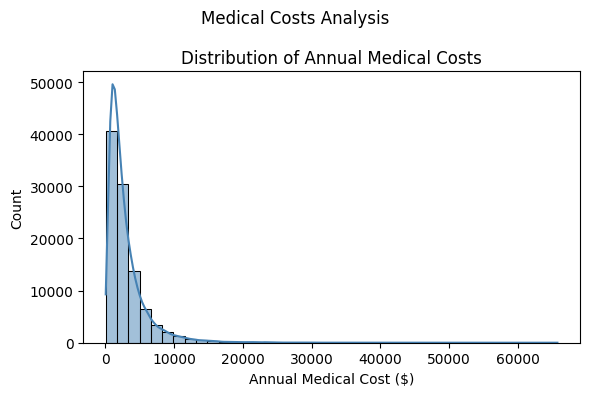

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(6, 4))
fig.suptitle('Medical Costs Analysis')
sns.histplot(df['annual_medical_cost'], bins=40, kde=True, ax=ax, color='steelblue')
ax.set_title('Distribution of Annual Medical Costs')
ax.set_xlabel('Annual Medical Cost ($)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show();

## 3 - Split data

In [11]:
X = df.drop(columns=['annual_medical_cost'])
y = df['annual_medical_cost']

In [12]:
X.shape , y.shape

((100000, 53), (100000,))

In [61]:
def preprocessing(data):

    # drop some coulmns
    cols_to_drop = ['monthly_premium', 'person_id']
    existing_cols = [col for col in cols_to_drop if col in data.columns]
    data = data.drop(columns=existing_cols)


    # handle missing
    data = simpleimputer(data)

    # scalling
    data = standardscaler(data)
    data = minmaxscaler(data)

    # encoding
    # for oridnal column
    data = ordinalencoder(data)
    # for the rest of data
    data = onehotencoder(data)

    # normalizing
    # after onehot encoder
    data = normalize_column_names(data)

    # Convert any remaining object columns to numeric, coercing errors to NaN
    for col in data.select_dtypes(include='object').columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

    # Drop any columns that couldn't be converted to numeric and contain NaN
    data = data.dropna(axis=1)


    return data

In [14]:
X_preproc = preprocessing(X)
X_preproc

,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,...,smoker_current,smoker_former,smoker_never,alcohol_freq_daily,alcohol_freq_occasional,alcohol_freq_weekly,plan_type_epo,plan_type_hmo,plan_type_pos,plan_type_ppo
0,0.280105,0.020364,0.250,0.142857,0.081982,0.08,0.0,0.0,0.363636,0.207626,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,1.968800,0.011030,0.250,0.142857,-0.078183,0.08,0.0,0.0,0.272727,0.858282,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.280813,0.037334,0.500,0.428571,0.902826,0.04,0.0,0.0,0.363636,2.745184,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,-2.034034,0.013670,0.500,0.428571,0.922847,0.00,0.0,0.0,0.090909,-0.898489,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.342649,0.083435,0.125,0.000000,0.702620,0.12,0.0,0.0,0.181818,1.183610,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.155016,0.118884,0.125,0.000000,0.242147,0.00,0.0,0.0,0.090909,-0.182767,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
99996,-0.345338,0.019327,0.125,0.000000,0.122023,0.00,0.0,0.0,0.090909,-1.093685,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
99997,-0.407883,0.076176,0.000,0.000000,0.562476,0.28,0.0,0.0,0.090909,0.663085,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
99998,0.217560,0.039879,0.250,0.285714,-1.019151,0.16,0.0,0.0,0.181818,-0.508095,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 4- **Import** + **reusable function**

In [16]:
!pip install xgboost

In [17]:
from sklearn.ensemble import GradientBoostingRegressor,RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import learning_curve,cross_validate,GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [18]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=3,
        scoring='r2',
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    plt.figure(figsize=(5,4))
    plt.plot(train_sizes, train_mean, label='Training Score', color='royalblue')
    plt.plot(train_sizes, val_mean, label='Validation Score', color='darkorange')
    plt.title(f'Learning Curve: {title}')
    plt.xlabel('Training Set Size')
    plt.ylabel('R² Score')
    plt.legend()
    plt.grid(True)
    plt.ylim(-1, 1)
    plt.tight_layout()
    plt.show()

In [19]:
def plot_residuals(pipe, X_test, y_test, model_name="Model"):
    y_pred = pipe.predict(X_test)
    residuals = y_test - y_pred


    plt.figure(figsize=(6, 5))
    plt.scatter(y_pred, residuals)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f"Residuals Plot - {model_name}")
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [20]:
def evaluate_model(name, model, X_test, y_test):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)
    return [name, mae, mse, rmse, r2]

## Modling


In [21]:
lr_model = LinearRegression()

pipe_lr = make_pipeline(FunctionTransformer(preprocessing), lr_model)

pipe_lr.fit(X_train, y_train)

Pipeline(steps=[('functiontransformer',
                 FunctionTransformer(func=<function preprocessing at 0x7ae737bdb6a0>)),
                ('linearregression', LinearRegression())])

In [22]:
results = []
results.append(evaluate_model("Linear Regression", pipe_lr, X_test, y_test))

results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R²"])
display(results_df)

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,476.204375,621176.550813,788.147544,0.938519


In [23]:
cv_results = cross_validate(pipe_lr, X_train, y_train, scoring="neg_root_mean_squared_error", cv=3, return_train_score=True, n_jobs=-1)

print(f"\nCross-Validation RMSE Score:")
print(f"Train RMSE Mean: {-cv_results['train_score'].mean():.3f}")
print(f"Test RMSE Mean:  {-cv_results['test_score'].mean():.3f}")


Cross-Validation RMSE Score:
Train RMSE Mean: 577.364
Test RMSE Mean:  2381.183


In [24]:
tree_model = DecisionTreeRegressor(random_state=42,max_depth=5, min_samples_split=40, min_samples_leaf=20, max_features=0.8)

pipe_tree = make_pipeline(FunctionTransformer(preprocessing), tree_model)

pipe_tree.fit(X_train, y_train)


Pipeline(steps=[('functiontransformer',
                 FunctionTransformer(func=<function preprocessing at 0x7ae737bdb6a0>)),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(max_depth=5, max_features=0.8,
                                       min_samples_leaf=20,
                                       min_samples_split=40,
                                       random_state=42))])

In [25]:
results = []
results.append(evaluate_model("DecisionTree Regression", pipe_tree, X_test, y_test))

results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R²"])
display(results_df)

,Model,MAE,MSE,RMSE,R²
0,DecisionTree Regression,512.164097,792810.835045,890.399256,0.921532


In [26]:
cv_results = cross_validate(pipe_tree, X_train, y_train, scoring="neg_root_mean_squared_error", cv=3, return_train_score=True, n_jobs=-1)

print(f"\nCross-Validation RMSE Score:")
print(f"Train RMSE Mean: {-cv_results['train_score'].mean():.3f}")
print(f"Test RMSE Mean:  {-cv_results['test_score'].mean():.3f}")


Cross-Validation RMSE Score:
Train RMSE Mean: 597.238
Test RMSE Mean:  2378.166


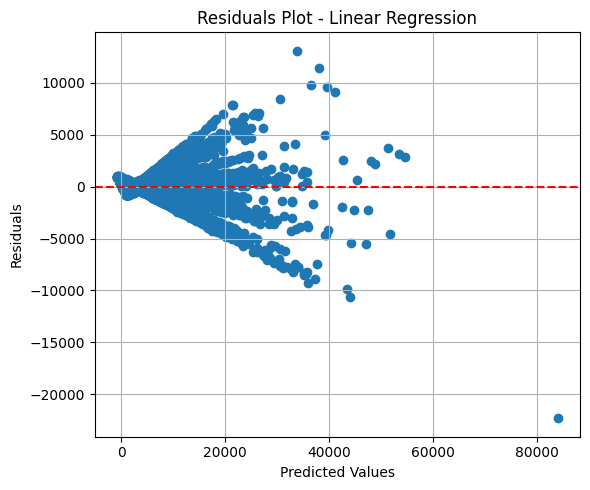

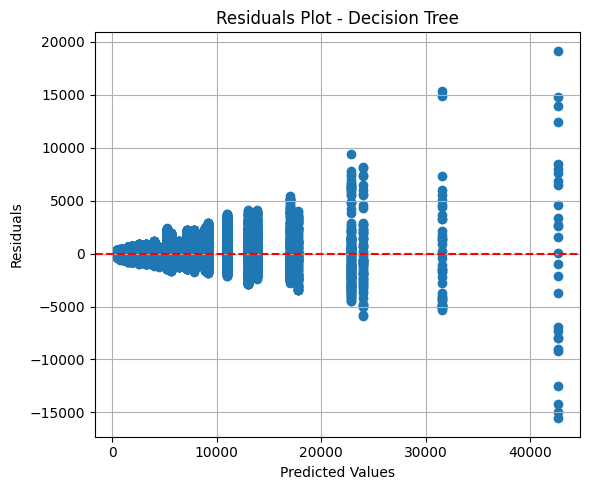

In [27]:
models = [
    (pipe_lr, "Linear Regression"),
    (pipe_tree, "Decision Tree")]

for model, name in models:
    plot_residuals(model, X_train, y_train, name)

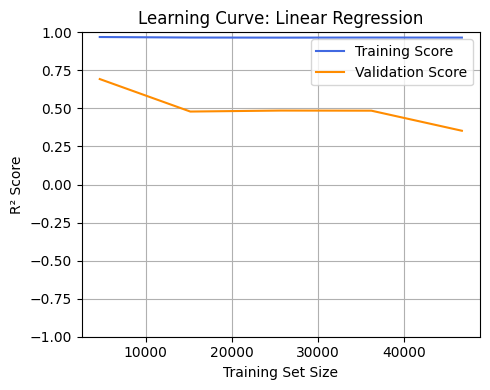

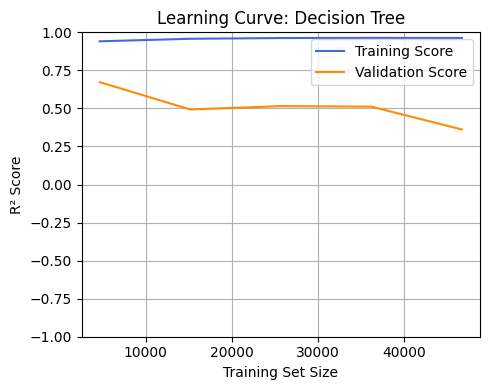

In [28]:
models = [
    (pipe_lr, "Linear Regression"),
    (pipe_tree, "Decision Tree")]

for model, name in models:
    plot_learning_curve(model, X_train, y_train, name)

In [29]:
lasso = Lasso(max_iter=10000, random_state=42)
pipe_lasso = make_pipeline(FunctionTransformer(preprocessing), lasso)

param_grid_lasso = {'lasso__alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

lasso_grid = GridSearchCV(pipe_lasso, param_grid_lasso, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1)
lasso_grid.fit(X_train, y_train)

print("Best Params for Lasso:", lasso_grid.best_params_)
print("Best RMSE (CV):", -lasso_grid.best_score_)

Best Params for Lasso: {'lasso__alpha': 10}
Best RMSE (CV): 2140.704106863944


In [30]:
param_grid_tree = {
    'decisiontreeregressor__max_depth': [3, 5, 7, 9],
    'decisiontreeregressor__min_samples_split': [2, 5, 10, 20],
    'decisiontreeregressor__min_samples_leaf': [1, 2, 5, 10]
}
tree_grid = GridSearchCV(pipe_tree, param_grid_tree, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1)
tree_grid.fit(X_train, y_train)
print("Best Params for Decision Tree:", tree_grid.best_params_)

Best Params for Decision Tree: {'decisiontreeregressor__max_depth': 5, 'decisiontreeregressor__min_samples_leaf': 10, 'decisiontreeregressor__min_samples_split': 2}


In [31]:
results = []
results.append(evaluate_model("Linear Regression", pipe_lr, X_test, y_test))
results.append(evaluate_model("Decision Tree", pipe_tree, X_test, y_test))

results.append(evaluate_model("Lasso (Tuned)", lasso_grid.best_estimator_, X_test, y_test))
results.append(evaluate_model("Decision Tree (Tuned)", tree_grid.best_estimator_, X_test, y_test))

results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R²"])
display(results_df)

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,476.204375,621176.550813,788.147544,0.938519
1,Decision Tree,512.164097,792810.835045,890.399256,0.921532
2,Lasso (Tuned),482.345389,508632.653339,713.184866,0.949658
3,Decision Tree (Tuned),510.869492,765652.160022,875.015520,0.924220


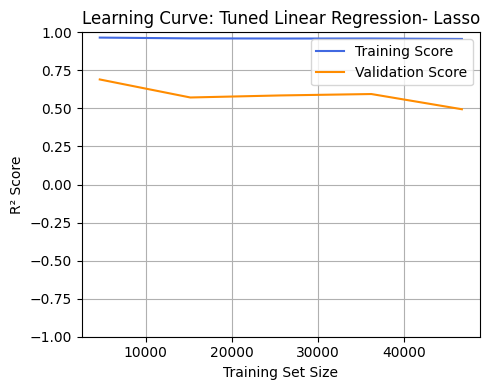

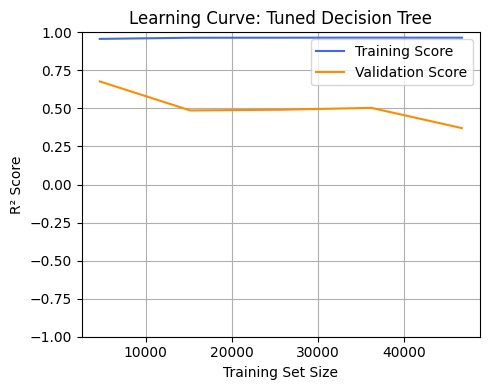

In [32]:
models = [
    (lasso_grid.best_estimator_, "Tuned Linear Regression- Lasso"),
    (tree_grid.best_estimator_, "Tuned Decision Tree")]

for model, name in models:
    plot_learning_curve(model, X_train, y_train, name)

In [33]:
ridge_model = Ridge(alpha=1.0)
pipe_ridge = make_pipeline(FunctionTransformer(preprocessing), ridge_model)

pipe_ridge.fit(X_train, y_train)

Pipeline(steps=[('functiontransformer',
                 FunctionTransformer(func=<function preprocessing at 0x7ae737bdb6a0>)),
                ('ridge', Ridge())])

In [34]:
results = []
results.append(evaluate_model("Ridge Regression", pipe_ridge, X_test, y_test))

results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R²"])
display(results_df)

,Model,MAE,MSE,RMSE,R²
0,Ridge Regression,465.717912,583027.922116,763.562651,0.942295


In [35]:
cv_results = cross_validate(pipe_ridge, X_train, y_train, scoring="neg_root_mean_squared_error", cv=3, return_train_score=True, n_jobs=-1)

print(f"\nCross-Validation RMSE Score:")
print(f"Train RMSE Mean: {-cv_results['train_score'].mean():.3f}")
print(f"Test RMSE Mean:  {-cv_results['test_score'].mean():.3f}")


Cross-Validation RMSE Score:
Train RMSE Mean: 580.127
Test RMSE Mean:  2323.318


In [36]:
knn_model  = KNeighborsRegressor(n_neighbors=5)
pipe_knn = make_pipeline(FunctionTransformer(preprocessing), knn_model)

pipe_knn.fit(X_train, y_train)

Pipeline(steps=[('functiontransformer',
                 FunctionTransformer(func=<function preprocessing at 0x7ae737bdb6a0>)),
                ('kneighborsregressor', KNeighborsRegressor())])

In [37]:
results = []
results.append(evaluate_model("KNN Regression", pipe_knn, X_test, y_test))

results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R²"])
display(results_df)

,Model,MAE,MSE,RMSE,R²
0,KNN Regression,1946.633152,1.049168e+07,3239.086805,-0.038413


In [38]:
cv_results = cross_validate(pipe_knn, X_train, y_train, scoring="neg_root_mean_squared_error", cv=3, return_train_score=True, n_jobs=-1)

print(f"\nCross-Validation RMSE Score:")
print(f"Train RMSE Mean: {-cv_results['train_score'].mean():.3f}")
print(f"Test RMSE Mean:  {-cv_results['test_score'].mean():.3f}")


Cross-Validation RMSE Score:
Train RMSE Mean: 2577.278
Test RMSE Mean:  3174.513


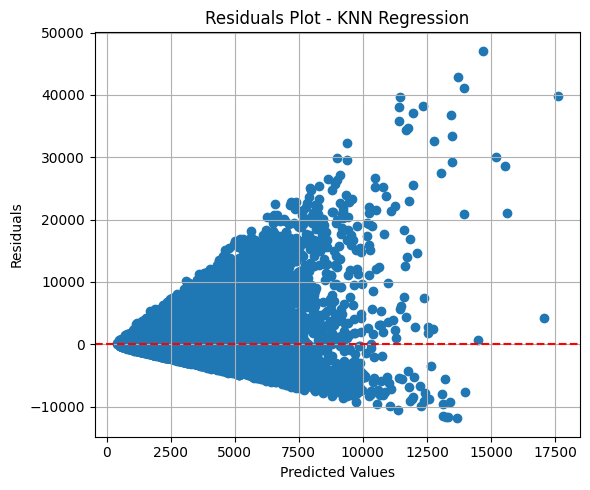

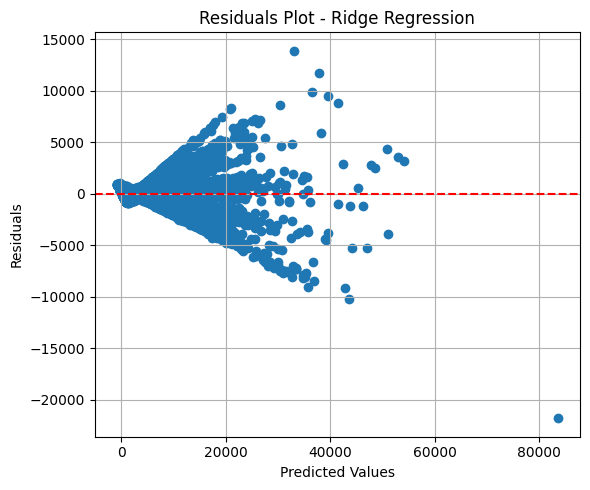

In [39]:
models = [
    (pipe_knn, "KNN Regression"),
    (pipe_ridge, "Ridge Regression")]

for model, name in models:
    plot_residuals(model, X_train, y_train, name)

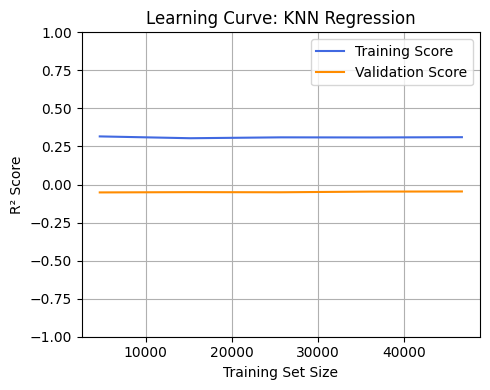

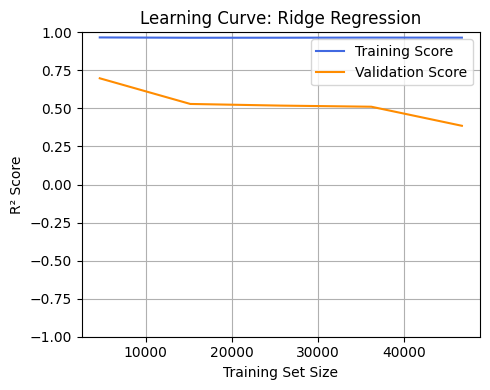

In [40]:
models = [
    (pipe_knn, "KNN Regression"),
    (pipe_ridge, "Ridge Regression")]

for model, name in models:
    plot_learning_curve(model, X_train, y_train, name)

In [41]:
param_grid = {'ridge__alpha': [0.1, 1, 10,50]}

ridge_grid = GridSearchCV(pipe_ridge, param_grid, cv=3, scoring="neg_root_mean_squared_error")
ridge_grid.fit(X_train, y_train)

print("Best Parameters:", ridge_grid.best_params_)
print("Best Score:", ridge_grid.best_score_)

Best Parameters: {'ridge__alpha': 50}
Best Score: -1481.8718513636595


In [42]:
knn_param_grid = {'kneighborsregressor__n_neighbors': [3, 5, 7, 9]}
knn_grid = GridSearchCV(pipe_knn, knn_param_grid, cv=3, scoring="neg_root_mean_squared_error")
knn_grid.fit(X_train, y_train)

print("Best Parameters:",knn_grid.best_params_)
print("Best Score:", knn_grid.best_score_)

Best Parameters: {'kneighborsregressor__n_neighbors': 9}
Best Score: -3095.9156097763903


In [43]:
results = []
results.append(evaluate_model("Ridge Regression", pipe_ridge, X_test, y_test))
results.append(evaluate_model("KNN Regression", pipe_knn, X_test, y_test))

results.append(evaluate_model("Ridge Regression (tuned)", ridge_grid.best_estimator_, X_test, y_test))
results.append(evaluate_model("KNN Regression (Tuned)", knn_grid.best_estimator_, X_test, y_test))

results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R²"])
display(results_df)

,Model,MAE,MSE,RMSE,R²
0,Ridge Regression,465.717912,5.830279e+05,763.562651,0.942295
1,KNN Regression,1946.633152,1.049168e+07,3239.086805,-0.038413
2,Ridge Regression (tuned),701.132775,1.127924e+06,1062.037804,0.888364
3,KNN Regression (Tuned),1875.402532,1.006256e+07,3172.153172,0.004060


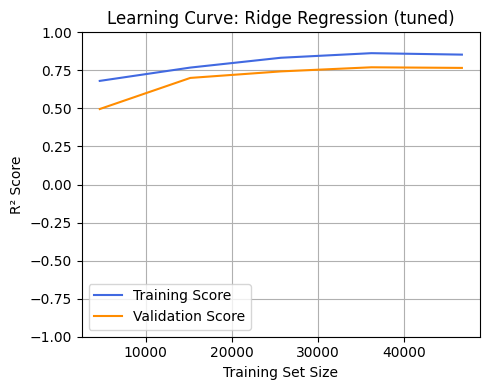

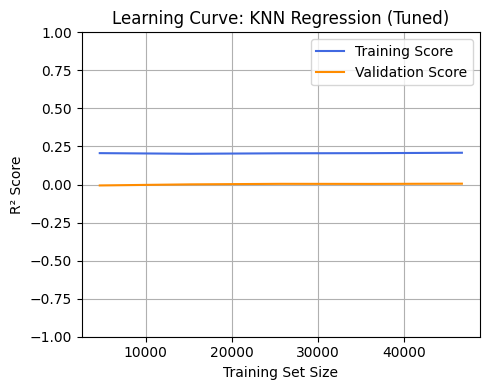

In [44]:
models = [
    (ridge_grid.best_estimator_, "Ridge Regression (tuned)"),
    (knn_grid.best_estimator_, "KNN Regression (Tuned)")]

for model, name in models:
    plot_learning_curve(model, X_train, y_train, name)

In [45]:
svr = SVR(kernel='rbf', C=50, gamma=0.1, epsilon=0.1)
pipe_svr = make_pipeline(FunctionTransformer(preprocessing), svr)

pipe_svr.fit(X_train, y_train)

Pipeline(steps=[('functiontransformer',
                 FunctionTransformer(func=<function preprocessing at 0x7ae737bdb6a0>)),
                ('svr', SVR(C=50, gamma=0.1))])

In [46]:
results = []
results.append(evaluate_model("Support Vector Regression", pipe_svr, X_test, y_test))

results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R²"])
display(results_df)

,Model,MAE,MSE,RMSE,R²
0,Support Vector Regression,1729.947203,1.012019e+07,3181.224848,-0.001644


In [47]:
cv_results = cross_validate(pipe_svr, X_train, y_train, scoring="neg_root_mean_squared_error", cv=3, return_train_score=True)

print(f"\nCross-Validation RMSE Score:")
print(f"Train RMSE Mean: {-cv_results['train_score'].mean():.3f}")
print(f"Test RMSE Mean:  {-cv_results['test_score'].mean():.3f}")


Cross-Validation RMSE Score:
Train RMSE Mean: 3096.576
Test RMSE Mean:  3116.422


In [48]:
randomforest = RandomForestRegressor(n_estimators=200, random_state=42)
pipe_rf = make_pipeline(FunctionTransformer(preprocessing), randomforest)

pipe_rf.fit(X_train, y_train)

Pipeline(steps=[('functiontransformer',
                 FunctionTransformer(func=<function preprocessing at 0x7ae737bdb6a0>)),
                ('randomforestregressor',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [49]:
results = []
results.append(evaluate_model("Random Forest Regressor", pipe_rf, X_test, y_test))

results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R²"])
display(results_df)

,Model,MAE,MSE,RMSE,R²
0,Random Forest Regressor,431.390331,389121.060287,623.795688,0.961487


In [50]:
cv_results = cross_validate(pipe_rf, X_train, y_train, scoring="neg_root_mean_squared_error", cv=3, return_train_score=True)

print(f"\nCross-Validation RMSE Score:")
print(f"Train RMSE Mean: {-cv_results['train_score'].mean():.3f}")
print(f"Test RMSE Mean:  {-cv_results['test_score'].mean():.3f}")


Cross-Validation RMSE Score:
Train RMSE Mean: 60.916
Test RMSE Mean:  2381.242


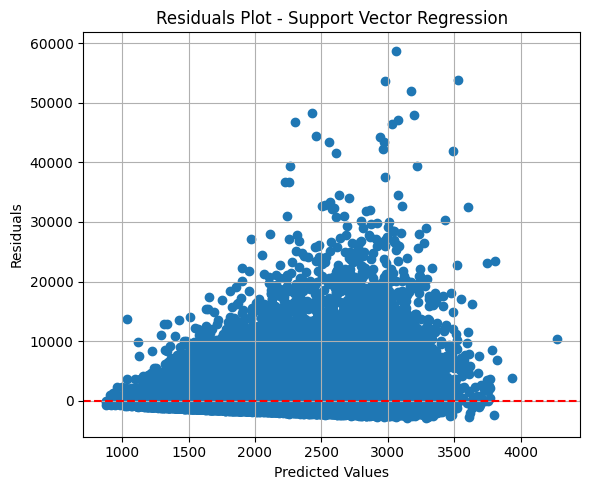

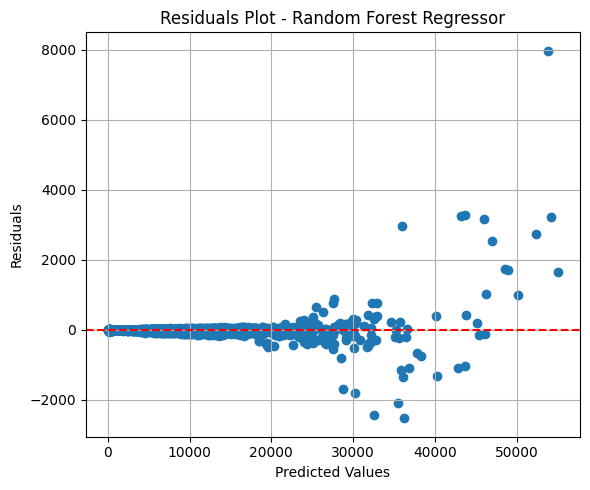

In [51]:
models = [
    (pipe_svr, "Support Vector Regression"),
    (pipe_rf, "Random Forest Regressor")]

for model, name in models:
    plot_residuals(model, X_train, y_train, name)

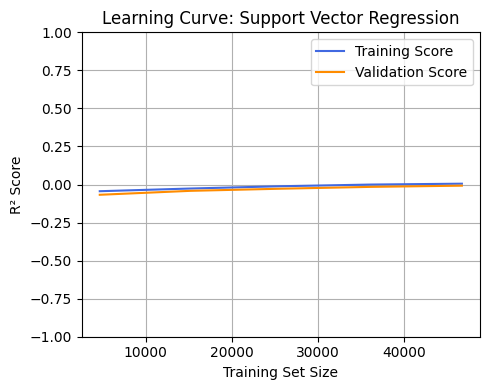

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


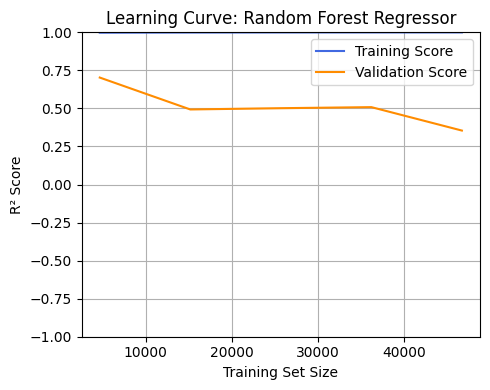

In [52]:
models = [
    (pipe_svr, "Support Vector Regression"),
    (pipe_rf, "Random Forest Regressor")]

for model, name in models:
    plot_learning_curve(model, X_train, y_train, name)

In [53]:
param_grid = {
    'randomforestregressor__n_estimators': [100, 200],
    'randomforestregressor__max_depth': [5,10],
    'randomforestregressor__min_samples_split': [ 5, 10]}

grid_rf = GridSearchCV(pipe_rf,param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3, n_jobs=-1)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best RMSE Score:", -grid_rf.best_score_)

Best Parameters: {'randomforestregressor__max_depth': 3, 'randomforestregressor__min_samples_split': 2, 'randomforestregressor__n_estimators': 200}
Best RMSE Score: 2266.807760543546


In [54]:
results = []
results.append(evaluate_model("Random Forest Regressor", pipe_rf, X_test, y_test))
results.append(evaluate_model("Support Vector Regression", pipe_svr, X_test, y_test))

results.append(evaluate_model("Random Forest Regressor (tuned)", grid_rf.best_estimator_, X_test, y_test))

results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R²"])
display(results_df)

,Model,MAE,MSE,RMSE,R²
0,Random Forest Regressor,431.390331,3.891211e+05,623.795688,0.961487
1,Support Vector Regression,1729.947203,1.012019e+07,3181.224848,-0.001644
2,Random Forest Regressor (tuned),649.709445,1.191989e+06,1091.782609,0.882023


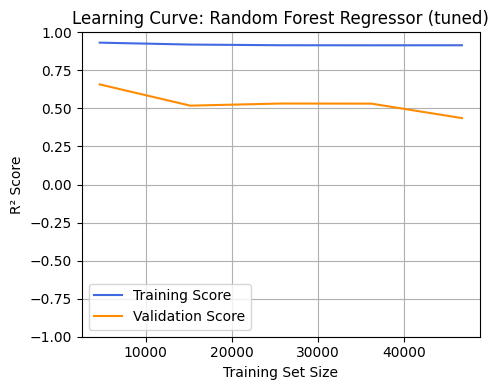

In [55]:
models = [
    (grid_rf.best_estimator_, "Random Forest Regressor (tuned)")]
for model, name in models:
    plot_learning_curve(model, X_train, y_train, name)

In [56]:
gboost = GradientBoostingRegressor(n_estimators=100, verbose=0)

pipe_gboost = make_pipeline(FunctionTransformer(preprocessing), gboost)

pipe_gboost.fit(X_train, y_train)

Pipeline(steps=[('functiontransformer',
                 FunctionTransformer(func=<function preprocessing at 0x7ae737bdb6a0>)),
                ('gradientboostingregressor', GradientBoostingRegressor())])

In [57]:
results = []
results.append(evaluate_model("Gradient Boosting Regressor", pipe_gboost, X_test, y_test))

results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R²"])
display(results_df)

,Model,MAE,MSE,RMSE,R²
0,Gradient Boosting Regressor,426.386067,359090.804396,599.241858,0.964459


In [62]:
cv_results = cross_validate(pipe_gboost, X_train, y_train, scoring="neg_root_mean_squared_error", cv=3, return_train_score=True)

print(f"\nCross-Validation RMSE Score:")
print(f"Train RMSE Mean: {-cv_results['train_score'].mean():.3f}")
print(f"Test RMSE Mean:  {-cv_results['test_score'].mean():.3f}")


Cross-Validation RMSE Score:
Train RMSE Mean: 77.150
Test RMSE Mean:  2368.049


In [63]:
xgb = XGBRegressor(max_depth=10,
                         n_estimators=150,
                         learning_rate=0.1)
pipe_xgb = make_pipeline(FunctionTransformer(preprocessing), xgb)

pipe_xgb.fit(X_train, y_train)

Pipeline(steps=[('functiontransformer',
                 FunctionTransformer(func=<function preprocessing at 0x7ae72cc11800>)),
                ('xgbregressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, feat...s=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=10, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=150, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [64]:
results = []
results.append(evaluate_model("XGBoosting Regressor", pipe_xgb, X_test, y_test))

results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R²"])
display(results_df)

,Model,MAE,MSE,RMSE,R²
0,XGBoosting Regressor,442.897292,711160.095489,843.303086,0.929613


In [65]:
cv_results = cross_validate(pipe_xgb, X_train, y_train, scoring="neg_root_mean_squared_error", cv=3, return_train_score=True)

print(f"\nCross-Validation RMSE Score:")
print(f"Train RMSE Mean: {-cv_results['train_score'].mean():.3f}")
print(f"Test RMSE Mean:  {-cv_results['test_score'].mean():.3f}")


Cross-Validation RMSE Score:
Train RMSE Mean: 10.625
Test RMSE Mean:  2395.325


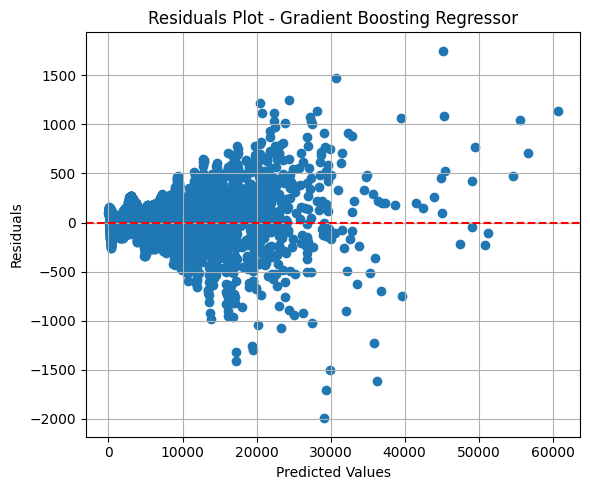

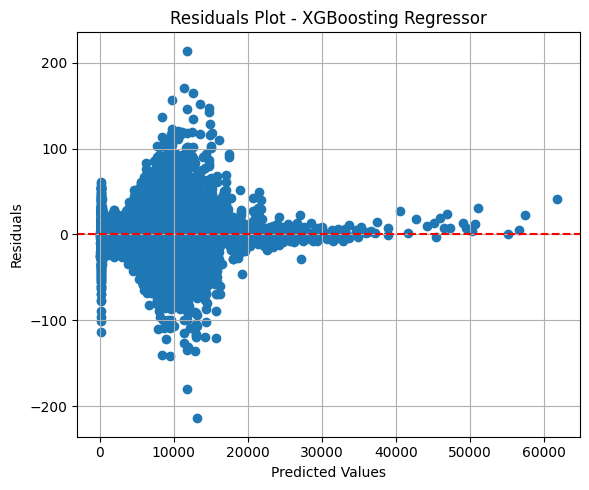

In [66]:
models = [
    (pipe_gboost, "Gradient Boosting Regressor"),
    (pipe_xgb, "XGBoosting Regressor")]

for model, name in models:
    plot_residuals(model, X_train, y_train, name)

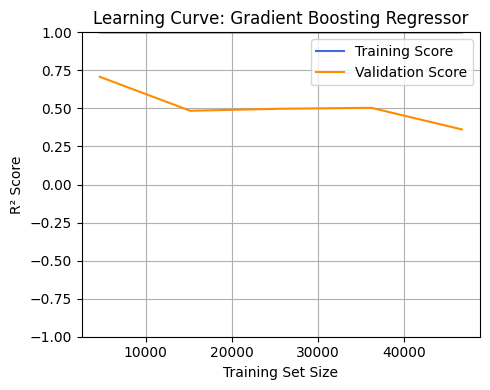

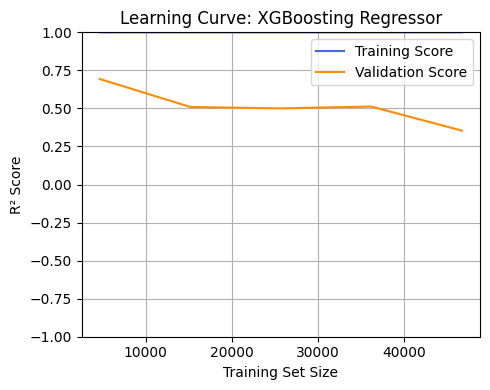

In [67]:
models = [
    (pipe_gboost, "Gradient Boosting Regressor"),
    (pipe_xgb, "XGBoosting Regressor")]

for model, name in models:
    plot_learning_curve(model, X_train, y_train, name)

In [68]:
grid = {'gradientboostingregressor__n_estimators': [30,50],
        'gradientboostingregressor__max_depth': [20,25],
        'gradientboostingregressor__max_features': [9,10],
        'gradientboostingregressor__learning_rate': [0.01,0.05],
        'gradientboostingregressor__subsample': [0.04,0.6],
        'gradientboostingregressor__min_samples_split': [10,15]}

search_gb = GridSearchCV(pipe_gboost, grid,scoring='neg_root_mean_squared_error', cv=3, n_jobs=-1,  verbose=1)
search_gb.fit(X_train, y_train)

print(f'Best params : {search_gb.best_params_}')
print(f'Best score : {-search_gb.best_score_}')

Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best params : {'gradientboostingregressor__learning_rate': 0.05, 'gradientboostingregressor__max_depth': 25, 'gradientboostingregressor__max_features': 10, 'gradientboostingregressor__min_samples_split': 15, 'gradientboostingregressor__n_estimators': 30, 'gradientboostingregressor__subsample': 0.6}
Best score : 1580.8388662612724


In [69]:
grid = {'xgbregressor__n_estimators':[50, 100],
        'xgbregressor__max_depth':[3, 5, 7],
        'xgbregressor__colsample':[3, 5, 7]}

search_xgb = GridSearchCV(pipe_xgb, grid, cv=3, n_jobs=-1,scoring='neg_root_mean_squared_error', verbose=0)
search_xgb.fit(X_train, y_train)

print(f'Best params : {search_xgb.best_params_}')
print(f'Best score : {-search_xgb.best_score_}')

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [03:37:56] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "colsample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params : {'xgbregressor__colsample': 3, 'xgbregressor__max_depth': 3, 'xgbregressor__n_estimators': 50}
Best score : 2292.8818234280875


In [70]:
results = []
results.append(evaluate_model("Gradient Boosting Regressor", pipe_gboost, X_test, y_test))
results.append(evaluate_model("XGBoosting Regressor", pipe_xgb, X_test, y_test))

results.append(evaluate_model("Gradient Boosting Regressor (tuned)", search_gb.best_estimator_, X_test, y_test))
results.append(evaluate_model("XGBoosting Regressor (tuned)", search_xgb.best_estimator_, X_test, y_test))


results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R²"])
display(results_df)

,Model,MAE,MSE,RMSE,R²
0,Gradient Boosting Regressor,426.386067,3.590908e+05,599.241858,0.964459
1,XGBoosting Regressor,442.897292,7.111601e+05,843.303086,0.929613
2,Gradient Boosting Regressor (tuned),610.907455,1.279003e+06,1130.930349,0.873411
3,XGBoosting Regressor (tuned),433.158730,6.635586e+05,814.591037,0.934324


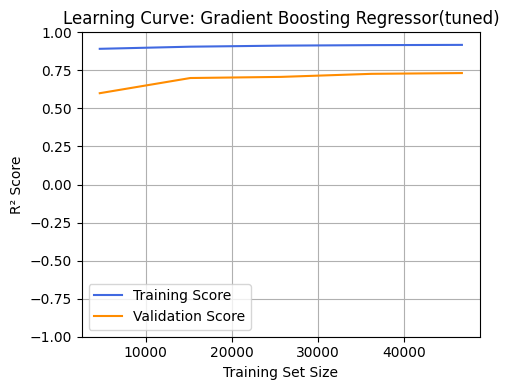

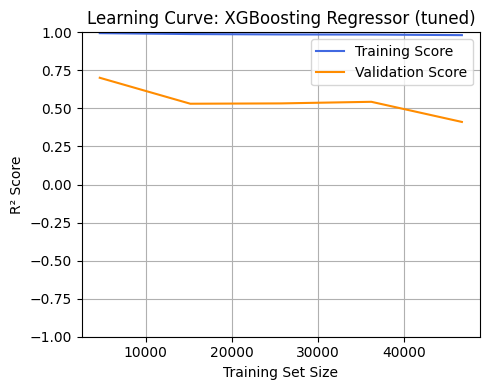

In [71]:
models = [
    (search_gb.best_estimator_, "Gradient Boosting Regressor(tuned)"),
    (search_xgb.best_estimator_, "XGBoosting Regressor (tuned)")]

for model, name in models:
    plot_learning_curve(model, X_train, y_train, name)

In [72]:
results = []

results.append(evaluate_model("Linear Regression", pipe_lr, X_test, y_test))
results.append(evaluate_model("Decision Tree", pipe_tree, X_test, y_test))
results.append(evaluate_model("Lasso (Tuned)", lasso_grid.best_estimator_, X_test, y_test))
results.append(evaluate_model("Decision Tree (Tuned)", tree_grid.best_estimator_, X_test, y_test))


results.append(evaluate_model("Ridge Regression", pipe_ridge, X_test, y_test))
results.append(evaluate_model("KNN Regression", pipe_knn, X_test, y_test))
results.append(evaluate_model("Ridge Regression (tuned)", ridge_grid.best_estimator_, X_test, y_test))
results.append(evaluate_model("KNN Regression (Tuned)", knn_grid.best_estimator_, X_test, y_test))

results.append(evaluate_model("Random Forest Regressor", pipe_rf, X_test, y_test))
results.append(evaluate_model("Support Vector Regression", pipe_svr, X_test, y_test))
results.append(evaluate_model("Random Forest Regressor (tuned)", grid_rf.best_estimator_, X_test, y_test))

results.append(evaluate_model("Gradient Boosting Regressor", pipe_gboost, X_test, y_test))
results.append(evaluate_model("XGBoosting Regressor", pipe_xgb, X_test, y_test))
results.append(evaluate_model("Gradient Boosting Regressor (tuned)", search_gb.best_estimator_, X_test, y_test))
results.append(evaluate_model("XGBoosting Regressor (tuned)", search_xgb.best_estimator_, X_test, y_test))


results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R²"])
print ('Model performance summary:')
display(results_df)

Model performance summary:


,Model,MAE,MSE,RMSE,R²
0,Linear Regression,476.204375,6.211766e+05,788.147544,0.938519
1,Decision Tree,512.164097,7.928108e+05,890.399256,0.921532
2,Lasso (Tuned),482.345389,5.086327e+05,713.184866,0.949658
3,Decision Tree (Tuned),510.869492,7.656522e+05,875.015520,0.924220
4,Ridge Regression,465.717912,5.830279e+05,763.562651,0.942295
5,KNN Regression,1946.633152,1.049168e+07,3239.086805,-0.038413
6,Ridge Regression (tuned),701.132775,1.127924e+06,1062.037804,0.888364
7,KNN Regression (Tuned),1875.402532,1.006256e+07,3172.153172,0.004060
8,Random Forest Regressor,431.390331,3.891211e+05,623.795688,0.961487
9,Support Vector Regression,1729.947203,1.012019e+07,3181.224848,-0.001644


In [ ]:
from sklearn.inspection import permutation_importance

models = [pipe_gboost]
model_names = ['GradientBoosting']

for name, model in zip(model_names, models):
    permutation_score = permutation_importance(model, X, y, n_repeats=30, random_state=42,n_jobs=-1)

    importance_df = pd.DataFrame({
        'feature': X.columns,
        'feature_importance': permutation_score.importances_mean
    })

    print(f"\n{name} Feature Importance:")
    print(importance_df)

    filtered_df = X[importance_df[importance_df['feature_importance'] != 0.0]['feature']]

In [ ]:
filtered_df.columns